# Notebook to write down thought/solve the Multi-Armed Bandits part of the first homework

### 1. Does the modification of the problem result in an MAB or is the MDP formalism now more effective. 
 

The way we solved the first MAB was simply with a greedy implementation where we select a random arm with epsilon probability, if not take the one with current highest return, where return was simply current estimate of average reward from pulling an arm A, B or C. This worked reasonably well because the distribution of reward was static, which we no longer have. Question becomes if this change from static to dynamic reward makes this an MDP or if the MAB-formalization is still the best.. 


obs. Compared to an MDP, the MAB framework is simply an action, and a reward. note, MDP = states{}, actions{}, transition_prob{}, rewards{}, some discount factor \gamma? 

Feel like the new challenge is that with dynamic rewards, this feels somewhat similar to introducing states to the MAB, but it is not completely obvious how states should encode the info for changing rewards? maybe a "step counter" as state, and some param delta, s.t. when/if rewards suddenly change alot from current estimate, then interpret that as tolerance change? 

### 2.  min regret // max reward, change or adapt an MAB algo how? 

best guess yet is introducing another param, can probs expand prev algos s.a. decaying epsilon_greedy or ucb(upper confidence bound with heoffding ineq iirc.)

note after experimenting with algos, feel like min regret here would be a bad metric as the difference between optimal action reward and your reward rarely converge to zero as the distribution of rewards change

### 3. bandits_final, 1000 eps 

In [23]:
import numpy as np
from bandit import Bandits_final

# sketch some bandit algo to play the game, will have to adjust answer to task2 based on what works.
# implies a combo of theoretical knowledge and just trying stuff(empirical testing)... 

def custom_algo(MAB, episodes, hparam1, hparam2): #feel like time var could also be num_pulls
    num_arms = MAB.k

    #just random selection so far. 
    expected_rewards = np.zeros(num_arms)
    action_count = np.zeros(num_arms)

    actions = np.zeros(episodes, dtype=int)
    rewards = np.zeros(episodes)

    for ep in range(episodes):
        # re-choose a random arm at every iteration
        action = np.random.randint(num_arms)

        obs, reward, terminated, truncated, info = MAB.step(action)

        actions[ep] = action
        rewards[ep] = reward

        # update counts and rewards
        action_count[action] += 1
        expected_rewards[action] += (reward - expected_rewards[action]) / action_count[action]

    return expected_rewards, action_count, actions, rewards

In [79]:
# epsilon greedy implementation for comparison

def epsilon_greedy(MAB, episodes, epsilon9):
    num_arms = MAB.k

    expected_rewards = np.zeros(num_arms)
    action_count = np.zeros(num_arms)

    actions = np.zeros(episodes, dtype=int) 
    rewards = np.zeros(episodes)

    for episode in range(0, episodes):
        if np.random.rand() < epsilon9:
            action = np.random.randint(num_arms)  # Explore: choose a random arm
        else:
            action = np.argmax(expected_rewards)  # Exploit: choose the best arm

        obs, reward, terminated, truncated, info = MAB.step(action)

        actions[episode] = action
        rewards[episode] = reward

        # Update counts and rewards
        action_count[action] += 1
        expected_rewards[action] += (reward - expected_rewards[action]) / action_count[action]

    return expected_rewards, action_count, actions, rewards

In [83]:
# algo call 
MAB = Bandits_final()

eg_estimate, eg_count, eg_actions, eg_rewards = epsilon_greedy(MAB, episodes=1000, epsilon9=0.1)
print("Epsilon-Greedy Estimated Rewards:", eg_estimate)
print("Epsilon-Greedy Action Counts:", eg_count)
#print("Epsilon-Greedy Actions Taken:", eg_actions)
#print("Epsilon-Greedy Rewards Received:", eg_rewards)

print("\n")

custom_estimate, custom_count, custom_actions, custom_rewards = custom_algo(MAB, episodes=1000, hparam1=0, hparam2=0)
print("Custom Algo Estimated Rewards:", custom_estimate)
print("Custom Algo Action Counts:", custom_count)
#print("Custom Algo Actions Taken:", custom_actions)
#print("Custom Algo Rewards Received:", custom_rewards)






Epsilon-Greedy Estimated Rewards: [1.81849271 2.93834407 3.97926903]
Epsilon-Greedy Action Counts: [ 36. 590. 374.]


Custom Algo Estimated Rewards: [2.9335565  2.36229392 3.42039297]
Custom Algo Action Counts: [331. 341. 328.]


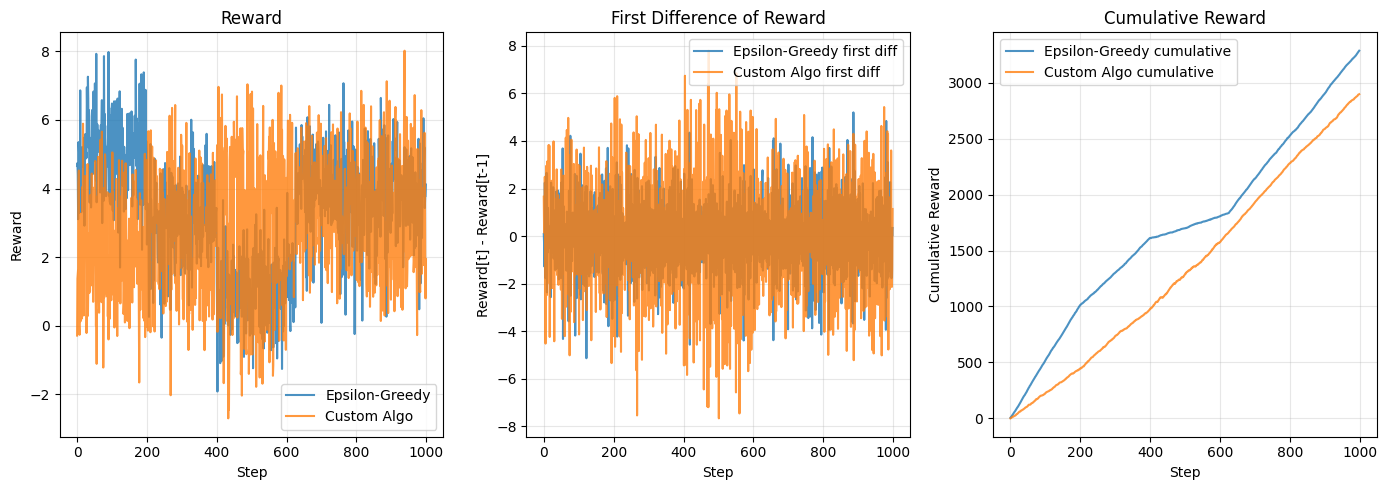

In [91]:
import matplotlib.pyplot as plt

def plot_reward_comparison(rewards_a, rewards_b, label_a="Agent A", label_b="Agent B"):
    #3 plots

    tot_rewards_a = np.cumsum(rewards_a)
    tot_rewards_b = np.cumsum(rewards_b)

    rewards_a = np.asarray(rewards_a)
    rewards_b = np.asarray(rewards_b)

    diff_a = np.diff(rewards_a)
    diff_b = np.diff(rewards_b)

    fig, axes = plt.subplots(1, 3,  figsize=(14, 5))

    # Left: rewards
    axes[0].plot(rewards_a, label=label_a, alpha=0.8)
    axes[0].plot(rewards_b, label=label_b, alpha=0.8)
    axes[0].set_title("Reward")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Reward")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Right: first differences
    axes[1].plot(diff_a, label=f"{label_a} first diff", alpha=0.8)
    axes[1].plot(diff_b, label=f"{label_b} first diff", alpha=0.8)
    axes[1].set_title("First Difference of Reward")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Reward[t] - Reward[t-1]")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(tot_rewards_a, label=f"{label_a} cumulative", alpha=0.8)
    axes[2].plot(tot_rewards_b, label=f"{label_b} cumulative", alpha=0.8)
    axes[2].set_title("Cumulative Reward")
    axes[2].set_xlabel("Step")
    axes[2].set_ylabel("Cumulative Reward")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)   

    plt.tight_layout()
    plt.show()

plot_reward_comparison(eg_rewards, custom_rewards, label_a="Epsilon-Greedy", label_b="Custom Algo") 


### 4. sep from solving, but notes for report


approach so far been ot eval changes from original mab, compare to an mdp, then reason what would best solve the new changes/how to fit new problem into either formalism. 

first sesh mostly consisted of reading material, understanding problem, and looking at returns from just selecting each arm with equal prob(selecting uniformly random). Think means change pretty quickly, can also just look at source code to infer that tbh. 

from looking at code, every 200 steps, the reward dist changes with prob 1/2, need to catch if rewards have changed to max total reward. 